## Categorising countries

### Data Source

The data used in this task was orginally sourced from Help.NGO. This international non-governmental organisation specialises in emergency response, preparedness, and risk mitigation.  

### Dataset Attributes
- country: name of the country
- child_mort: death of children under 5 years of age per 1000 live births
- exports: exports of goods and services per capita. Given as a percentage of the GDP per capita
- health: total health spending per capita. Given as a percentage of GDP per capita
- imports: imports of goods and services per capita. Given as a percentage of the GDP per capita
- income: net income per person
- inflation: the measurement of the annual growth rate of the Total GDP
- life_expec: the average number of years a new born child would live if the current mortality patterns remain the same
- total_fer: the number of children that would be born to each woman if the current age-fertility rates remains the same
- gdpp: the GDP per capita. Calculated as the Total GDP divided by the total population.

## Objective  
To group countries using socio-economic and health factors to determine the development status of the country.

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings(action='ignore', category=FutureWarning)
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Random state seed
rseed = 42

# Setting the stying of the Seaborn figure
sns.set_style('darkgrid')

## Load and explore data

In [3]:
df = pd.read_csv("Country-data.csv")
display(df.head())

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [4]:
print(df.shape)

(167, 10)


In [5]:
display(df.dtypes)
print(df.count())

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

country       167
child_mort    167
exports       167
health        167
imports       167
income        167
inflation     167
life_expec    167
total_fer     167
gdpp          167
dtype: int64


In [6]:
display(df.describe())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
print(df.isna().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Preprocessing and Feature Selection

In [8]:
df_numeric = df.select_dtypes(include=np.number).copy()
df_numeric["trade_openness"] = df_numeric["exports"] + df_numeric["imports"]
display(df_numeric.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_openness
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,54.9
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,76.6
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,69.8
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,105.2
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,104.4


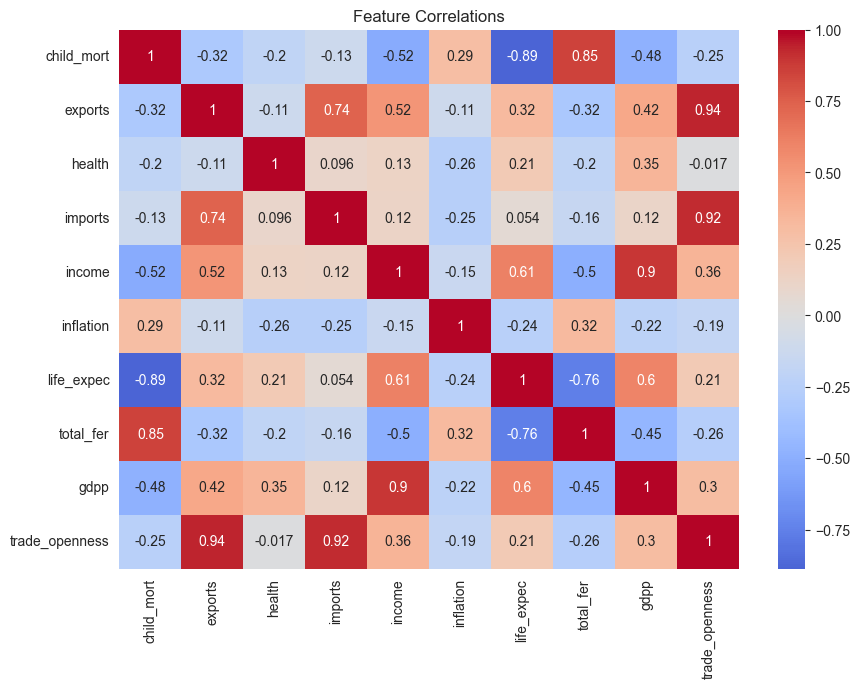

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Feature Correlations")
plt.show()

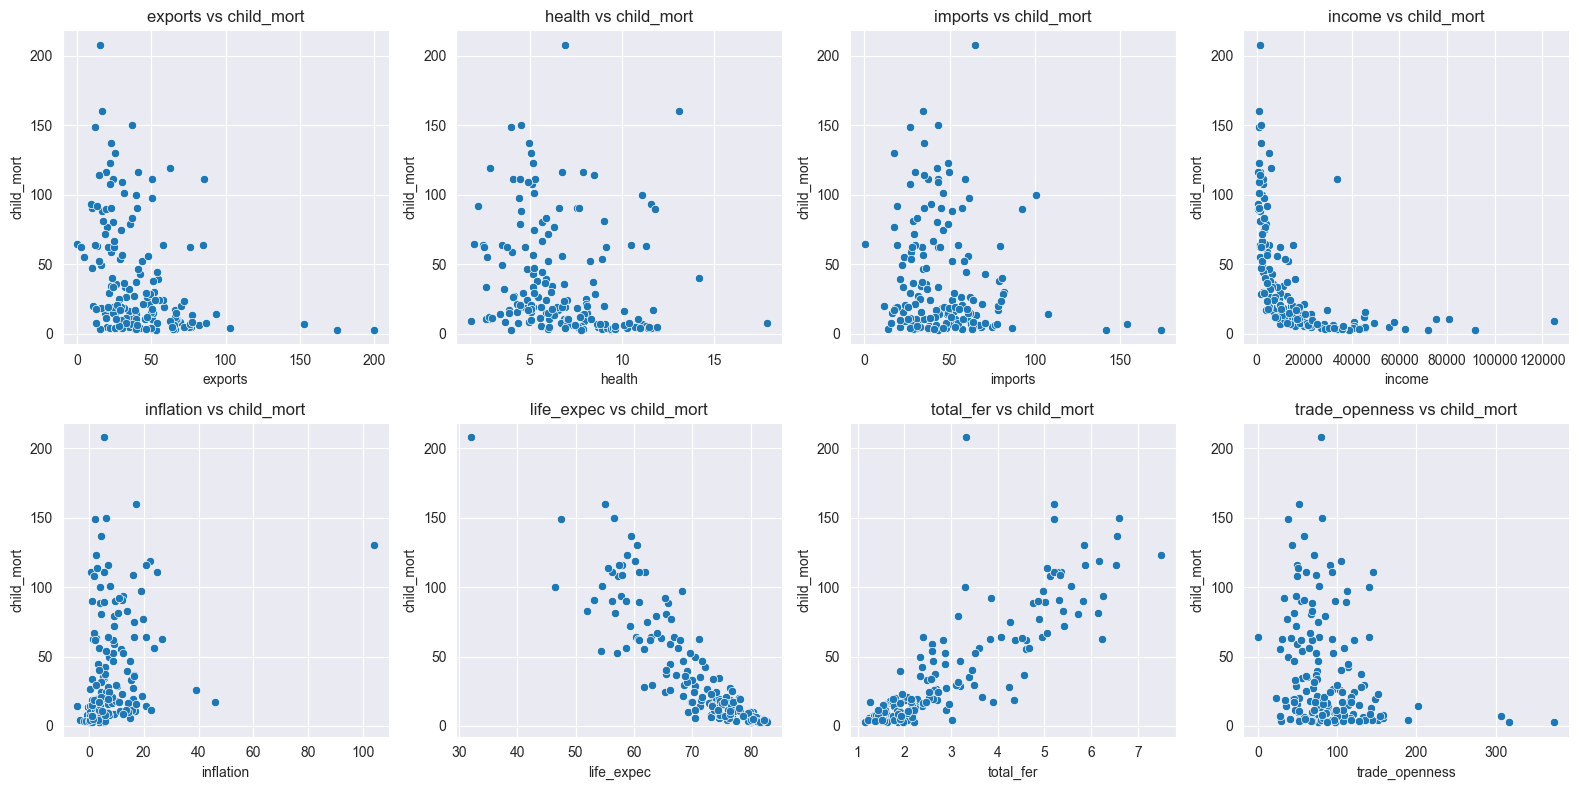

In [10]:
features = [column for column in df_numeric.columns if column not in ["gdpp", "child_mort"]]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for axis, feature in zip(axes.flat, features):
    sns.scatterplot(data=df_numeric, x=feature, y="child_mort", ax=axis)
    axis.set_title(f"{feature} vs child_mort")
plt.tight_layout()
plt.show()

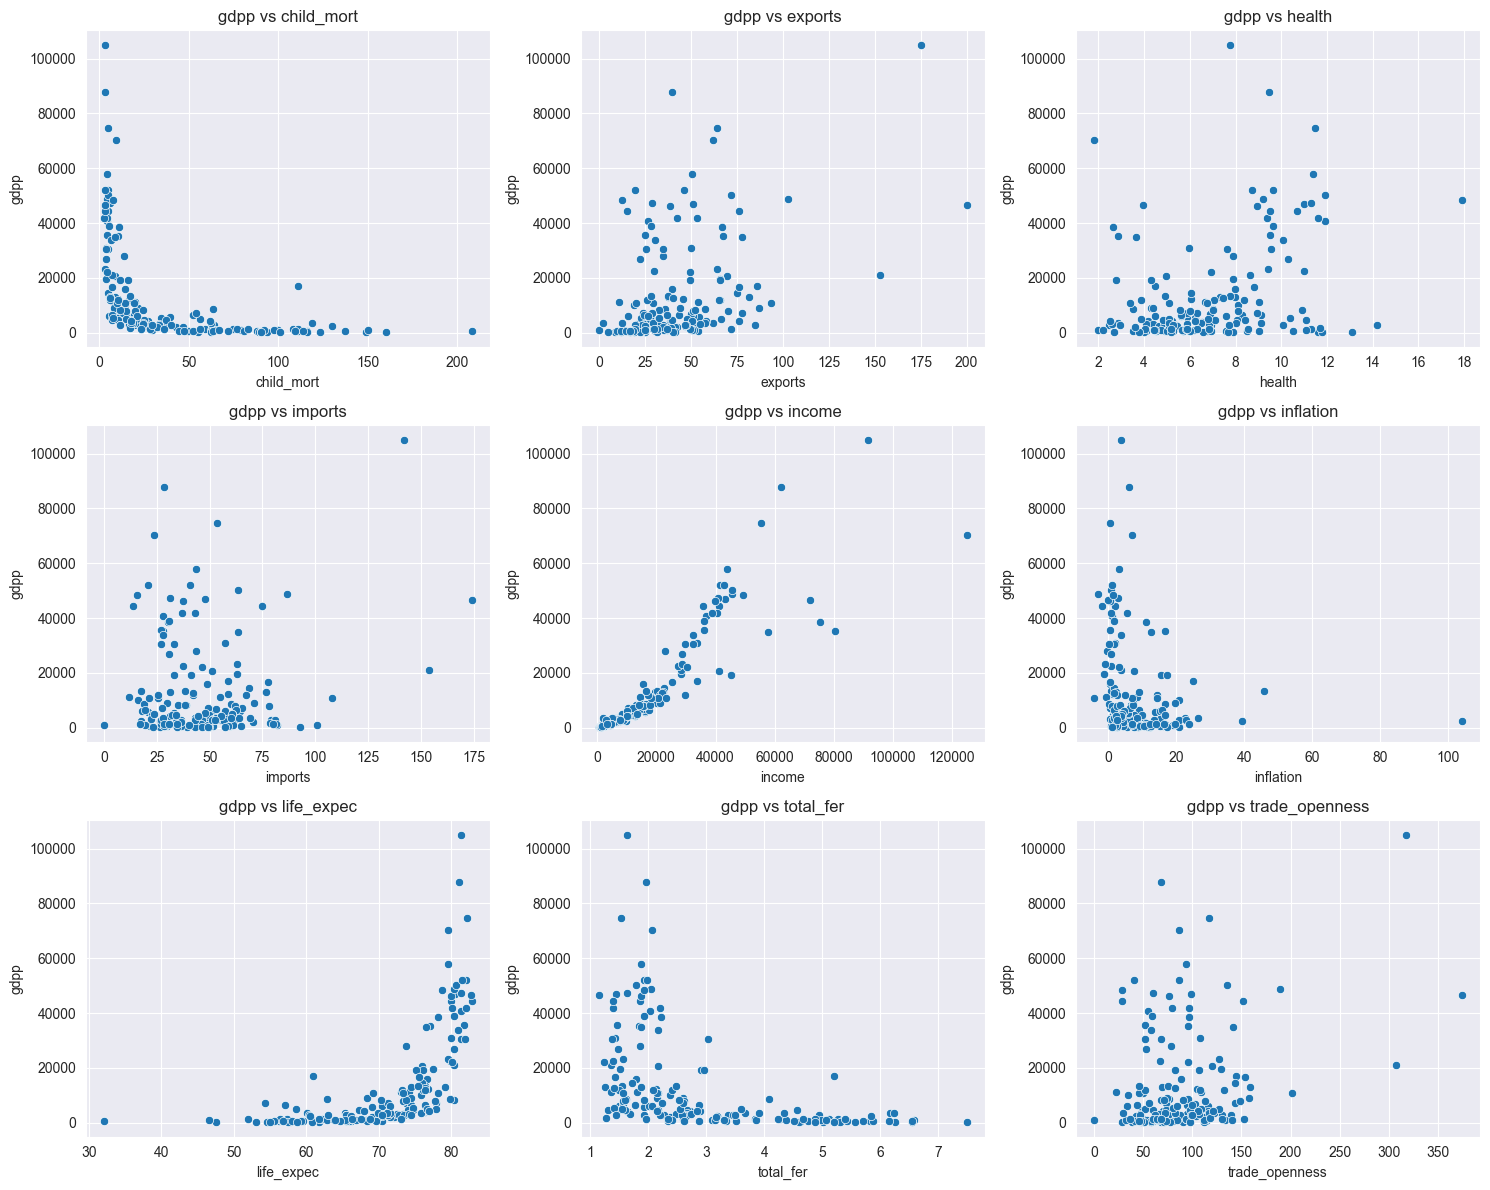

Most promising visual separation: gdpp vs income, health, and child_mort.


In [11]:
gdpp_features = [column for column in df_numeric.columns if column != "gdpp"]
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for axis, feature in zip(axes.flat, gdpp_features):
    sns.scatterplot(data=df_numeric, x=feature, y="gdpp", ax=axis)
    axis.set_title(f"gdpp vs {feature}")
plt.tight_layout()
plt.show()
print("Most promising visual separation: gdpp vs income, health, and child_mort.")

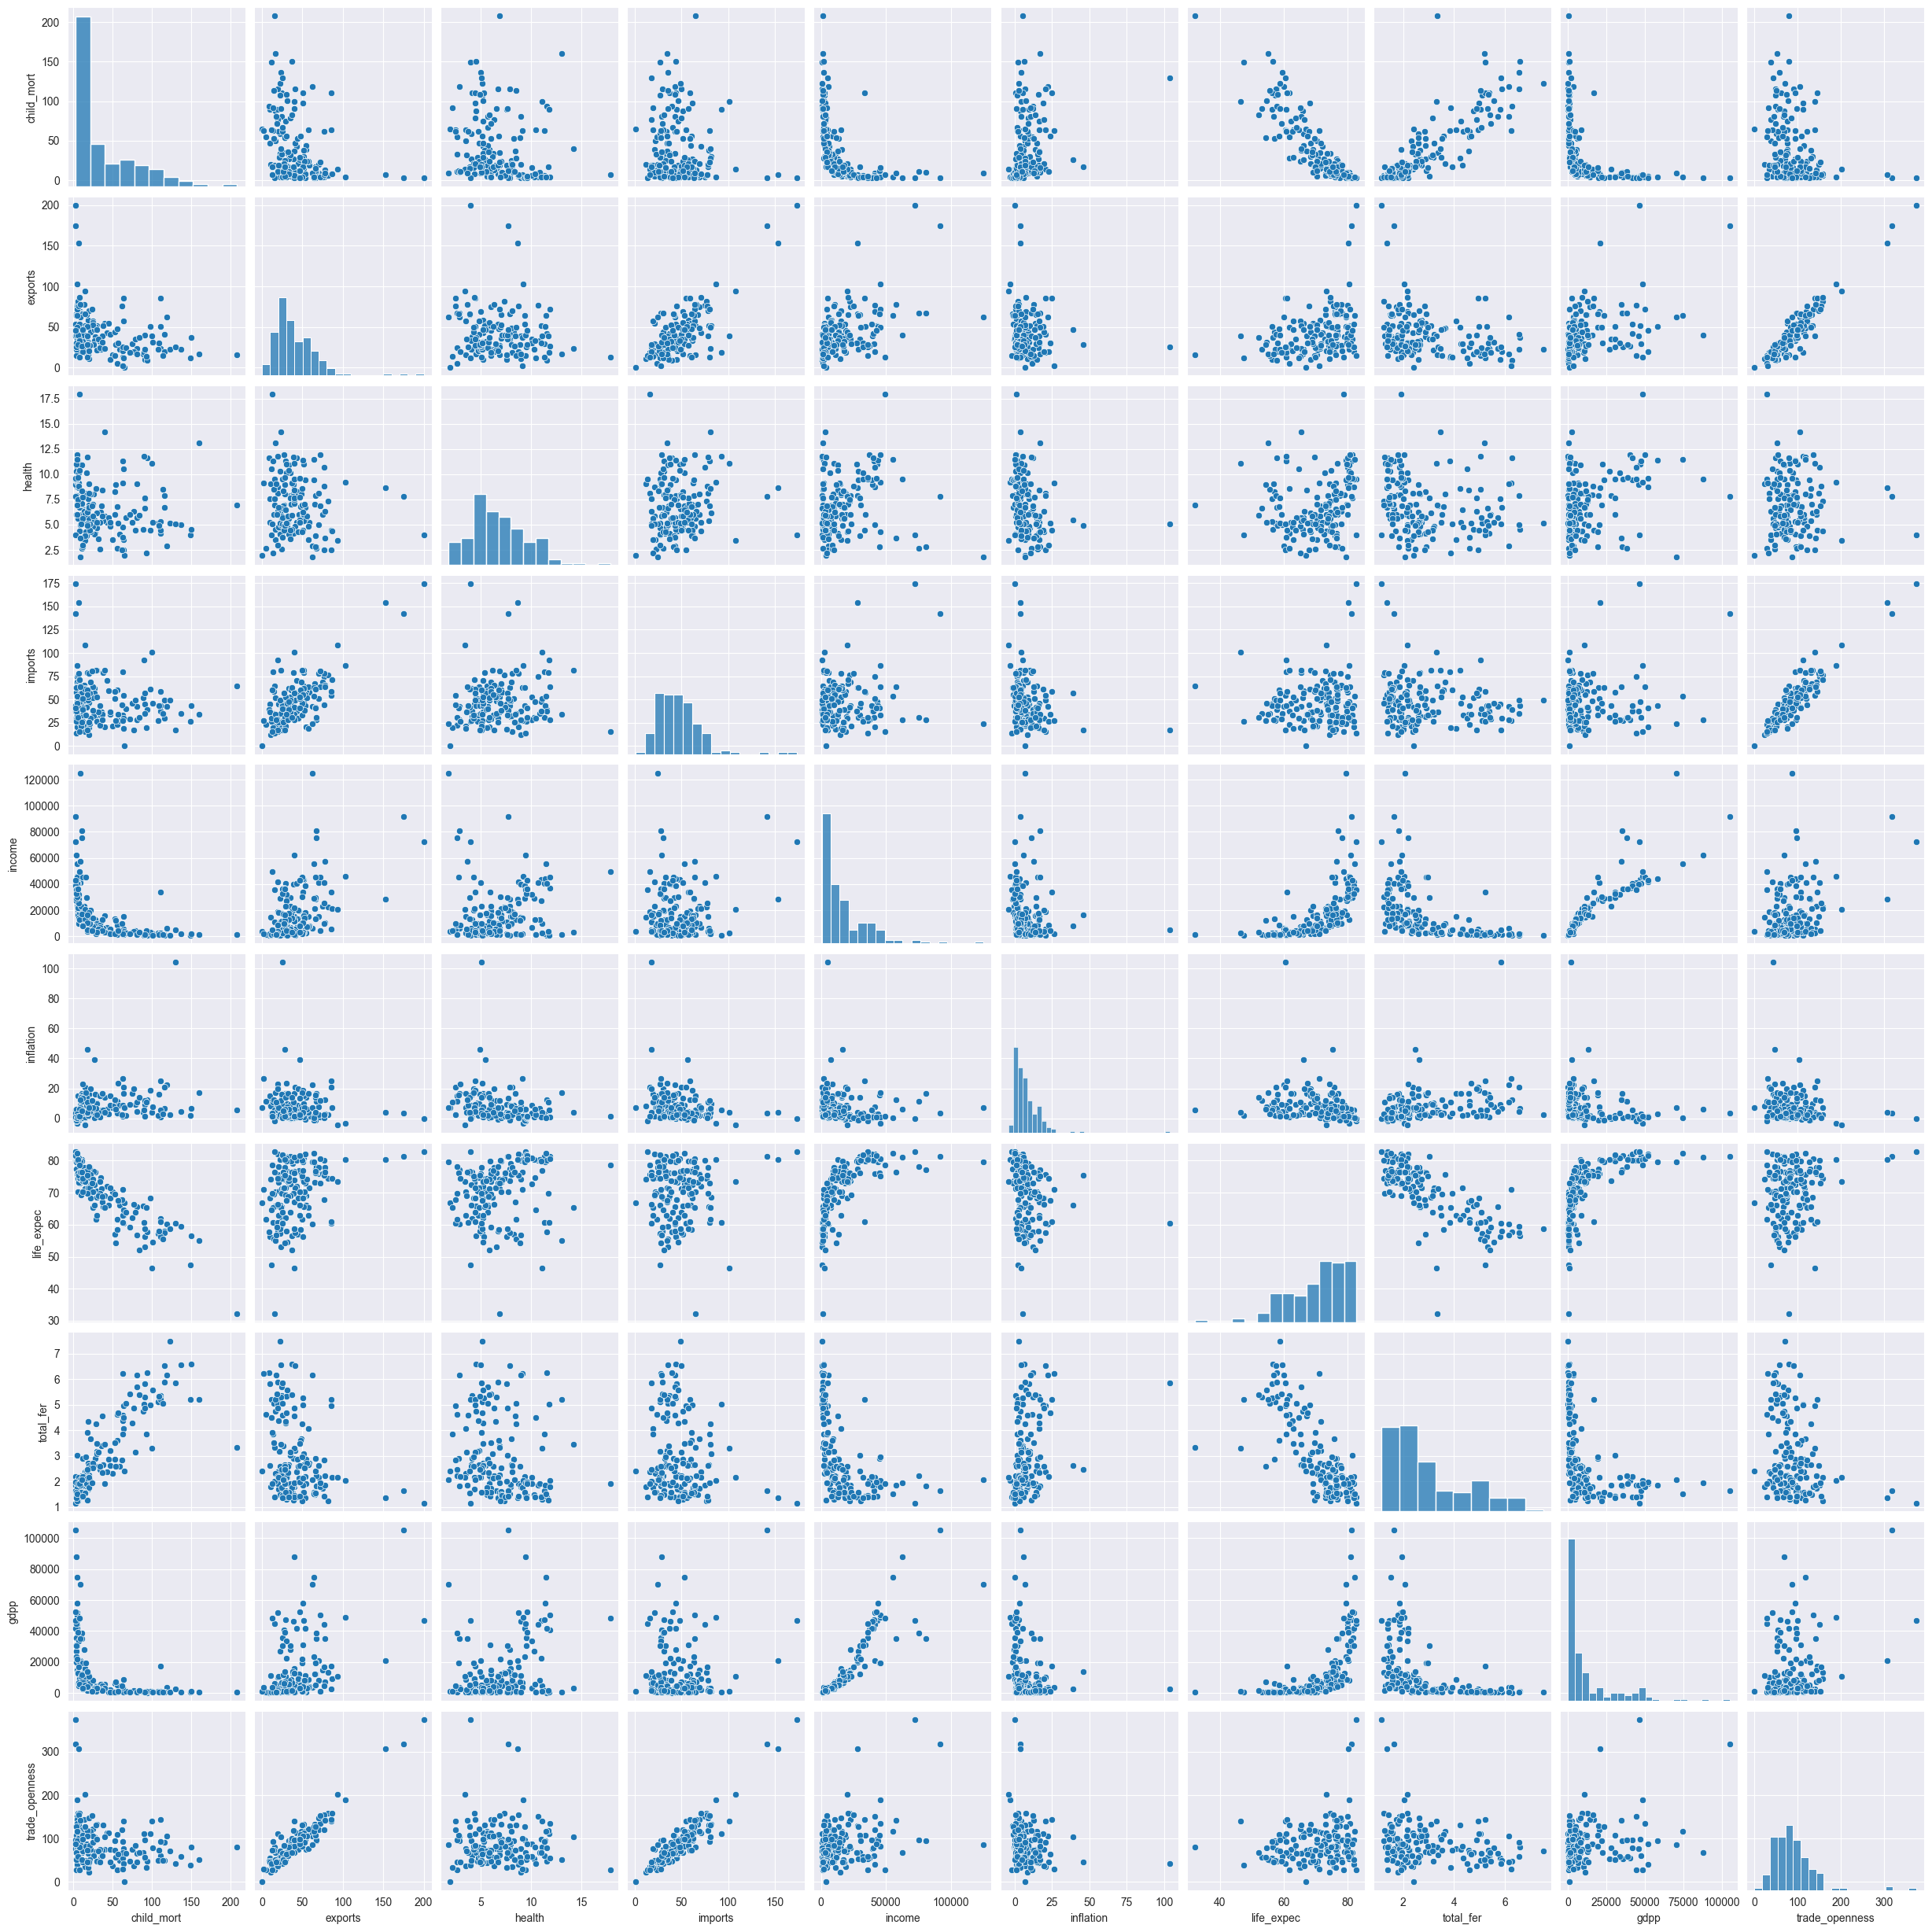

In [12]:
sns.pairplot(df_numeric)
plt.show()

Creating a pair plot is a helpful step in exploring the relationships between features before clustering data. The diagonal plots within a pair plot show the distribution of individual features, which can give insight into how the data is spread for each feature. While distinct peaks in these plots may hint at features with distinct ranges, true separability is better assessed by examining the off-diagonal plots, which show the relationships between pairs of features. These relationships provide a clearer view of how well the data might separate into clusters.

### Scaling the Data

In [13]:
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns, index=df_numeric.index)
display(df_scaled.head())

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_openness
0,0.426485,0.049482,0.358608,0.257765,0.008047,0.126144,0.475345,0.736593,0.003073,0.146392
1,0.068160,0.139531,0.294593,0.279037,0.074933,0.080399,0.871795,0.078864,0.036833,0.204441
2,0.120253,0.191559,0.146675,0.180149,0.098809,0.187691,0.875740,0.274448,0.040365,0.186250
3,0.566699,0.311125,0.064636,0.246266,0.042535,0.245911,0.552268,0.790221,0.031488,0.280947
4,0.037488,0.227079,0.262275,0.338255,0.148652,0.052213,0.881657,0.154574,0.114242,0.278807


## K-Means Clustering

### Selecting K

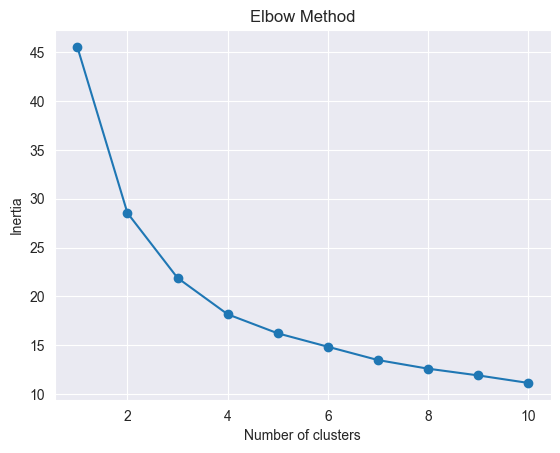

In [14]:
def eval_Kmeans(x, k, r):
    model = KMeans(n_clusters=k, random_state=r, n_init=10, max_iter=500)
    model.fit(x)
    return model.inertia_

def elbow_Kmeans(x, max_k=10, r=42):
    within_cluster_vars = [eval_Kmeans(x, k, r) for k in range(1, max_k + 1)]
    plt.plot(range(1, max_k + 1), within_cluster_vars, marker="o")
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.title("Elbow Method")
    plt.show()
    return within_cluster_vars

inertias = elbow_Kmeans(df_scaled)

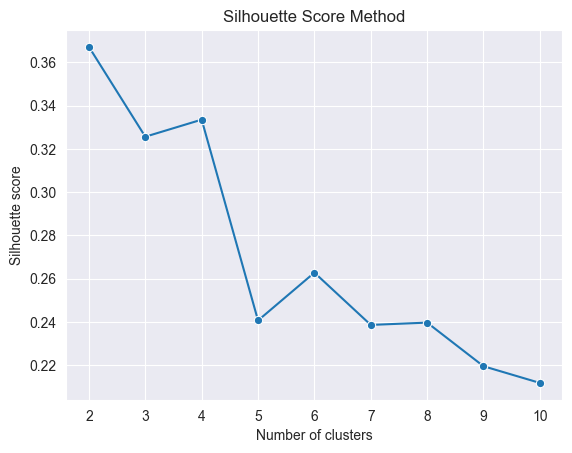

{2: 0.3672035915394151, 3: 0.3256802024179383, 4: 0.3335798399297425, 5: 0.24069609027290206, 6: 0.26282641446291455, 7: 0.23865140109313193, 8: 0.23971200885147065, 9: 0.2195486866339686, 10: 0.21182555461831576}
Selected k: 3 (elbow near 3 and strong silhouette score)


In [15]:
k_values = range(2, 11)
silhouette_scores = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=rseed, n_init=10, max_iter=500)
    labels = model.fit_predict(df_scaled)
    silhouette_scores.append(silhouette_score(df_scaled, labels))

sns.lineplot(x=list(k_values), y=silhouette_scores, marker="o")
plt.title("Silhouette Score Method")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()

silhouette_by_k = dict(zip(k_values, silhouette_scores))
print(silhouette_by_k)
optimal_k = 3
print("Selected k:", optimal_k, "(elbow near 3 and strong silhouette score)")

Based on the elbow and silhouette score method choose a value for K.

## Fitting a K-Means Model with the selected K value

In [17]:
# Fitting K-means model
kmeans_model = KMeans(n_clusters=optimal_k, random_state=rseed, n_init=10, max_iter=500)
kmeans_model.fit(df_scaled)
print(f"K-means model fitted with {optimal_k} clusters.")

K-means model fitted with 3 clusters.


In [18]:
print(pd.Series(kmeans_model.labels_).value_counts().sort_index())

0    87
1    45
2    35
Name: count, dtype: int64


In [19]:
model_silhouette_score = silhouette_score(df_scaled, kmeans_model.labels_)
print("Model silhouette score:", model_silhouette_score)

Model silhouette score: 0.3256802024179383


## Predictions

In [20]:
df_clustered = df.copy()
df_clustered["cluster"] = kmeans_model.labels_
cluster_summary = df_numeric.assign(cluster=kmeans_model.labels_).groupby("cluster")[["child_mort", "gdpp", "inflation"]].mean().sort_values("gdpp")
display(cluster_summary)

,child_mort,gdpp,inflation
cluster,,,
1,94.733333,1704.933333,12.214556
0,22.490805,6657.379310,7.599839
2,4.897143,43117.142857,2.535000


## Visualisation of clusters

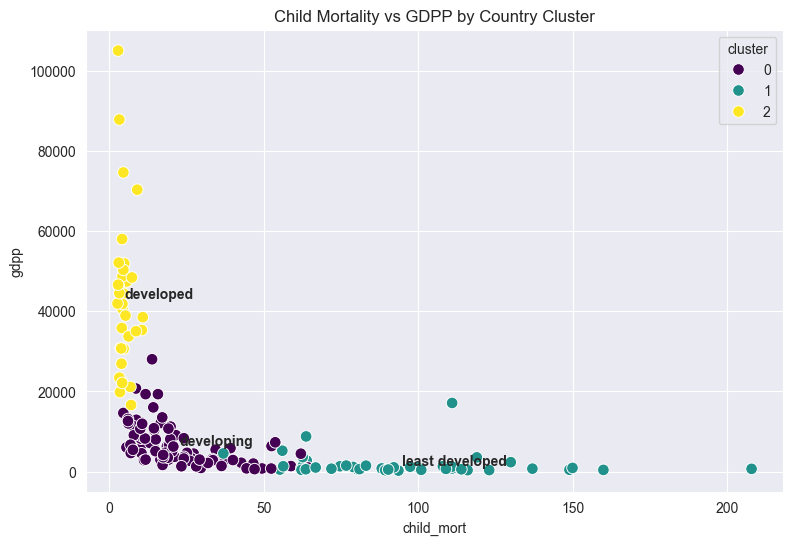

In [21]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clustered, x="child_mort", y="gdpp", hue="cluster", palette="viridis", s=70)
for cluster, row in cluster_summary.iterrows():
    label = "least developed" if row["gdpp"] == cluster_summary["gdpp"].min() else "developed" if row["gdpp"] == cluster_summary["gdpp"].max() else "developing"
    plt.text(df_clustered.loc[df_clustered["cluster"] == cluster, "child_mort"].mean(), row["gdpp"], label, weight="bold")
plt.title("Child Mortality vs GDPP by Country Cluster")
plt.show()

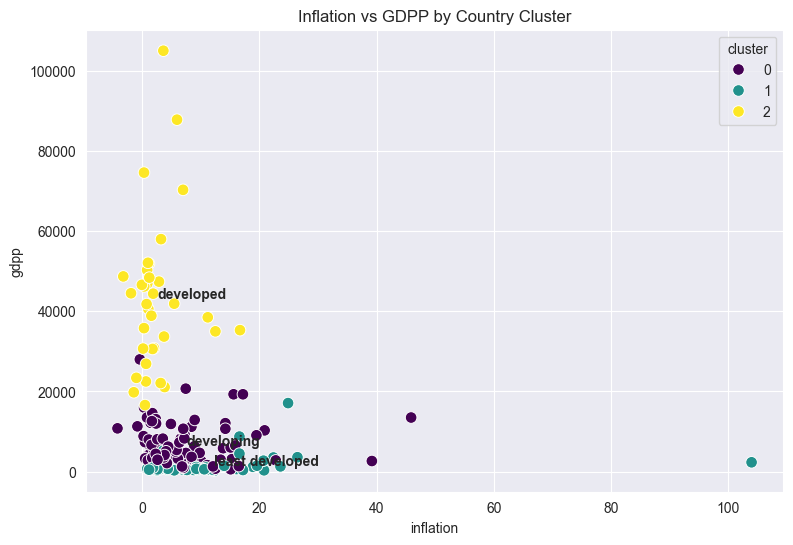

In [22]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_clustered, x="inflation", y="gdpp", hue="cluster", palette="viridis", s=70)
for cluster, row in cluster_summary.iterrows():
    label = "least developed" if row["gdpp"] == cluster_summary["gdpp"].min() else "developed" if row["gdpp"] == cluster_summary["gdpp"].max() else "developing"
    plt.text(df_clustered.loc[df_clustered["cluster"] == cluster, "inflation"].mean(), row["gdpp"], label, weight="bold")
plt.title("Inflation vs GDPP by Country Cluster")
plt.show()

## Conclusions

Label the groups of countries in the plots you created based on child mortality, GDPP and inflation. You may use [terms](https://en.wikipedia.org/wiki/Developing_country#Terms_used_to_classify_countries) such as: least developed, developing and developed, or low, low-middle, upper-middle and high income. Alternatively, simply rank them from highest to lowest. Justify the labels you assign to each group.


The clusters are labelled by their mean GDPP, supported by child mortality and inflation. The cluster with the lowest GDPP and generally higher child mortality is labelled least developed. The cluster with the highest GDPP and generally lower child mortality is labelled developed. The middle-GDPP cluster is labelled developing. These labels are relative group descriptions, not official country classifications; inflation is used as supporting context because higher inflation can indicate greater economic instability.